# Plot1 - CarbonSavings vs. MakeSpan

In [1]:
import pandas as pd
import glob
import os

root_dir = f"../Logs/GeneralExp"

# Define the pattern
pattern = "10J_5S_3O_MeanOp=3_v*.csv"

# Get list of matching files
csv_files = glob.glob(f"{root_dir}/{pattern}")

# Read and concatenate all files
df_union = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_union.shape}")

✅ Loaded and merged 8 files. Final shape: (3306, 20)


In [20]:
df_logs = df_union[["Instance", "IsCarbonAware", "Horizon", "MaxMakeSpan", "MinMakeSpan", "Makespan", "CarbonConsumption(g)"]]

In [16]:
df_logs.head(12)

,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,Makespan,CarbonConsumption(g)
0,0,False,288,288,14,14,745.00
1,0,True,288,14,14,14,745.00
2,0,True,288,28,14,23,745.00
3,0,True,288,70,14,20,745.00
4,0,True,288,140,14,17,745.00
5,0,True,288,288,14,264,355.83
6,1,False,288,288,21,21,1189.75
7,1,True,288,21,21,21,1187.00
8,1,True,288,42,21,24,1187.00
9,1,True,288,105,21,24,1187.00


In [21]:

# First, get baseline carbon consumption per instance where IsCarbonAware is False
baseline = df_logs[df_logs["IsCarbonAware"] == False][["Instance", "CarbonConsumption(g)"]]
baseline = baseline.rename(columns={"CarbonConsumption(g)": "BaselineCarbon"})
# Merge it back to original df to align baseline carbon for each instance
df_logs = df_logs.merge(baseline, on="Instance", how="left")
# Calculate savings
df_logs["CarbonSavings(%)"] = ((df_logs["BaselineCarbon"] - df_logs["CarbonConsumption(g)"]) / df_logs["BaselineCarbon"]) * 100
df_logs.drop(columns=["BaselineCarbon"], inplace=True)
# Optional: round to 2 decimal places
df_logs["CarbonSavings(%)"] = df_logs["CarbonSavings(%)"].round(2)


In [22]:
df_logs.head(12)

,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,Makespan,CarbonConsumption(g),CarbonSavings(%)
0,0,False,288,288,14,14,745.00,0.00
1,0,True,288,14,14,14,745.00,0.00
2,0,True,288,28,14,23,745.00,0.00
3,0,True,288,70,14,20,745.00,0.00
4,0,True,288,140,14,17,745.00,0.00
5,0,True,288,288,14,264,355.83,52.24
6,1,False,288,288,21,21,1189.75,0.00
7,1,True,288,21,21,21,1187.00,0.23
8,1,True,288,42,21,24,1187.00,0.23
9,1,True,288,105,21,24,1187.00,0.23


In [27]:
import pandas as pd

# Filter only carbon-aware rows
df_filtered = df_logs[df_logs["IsCarbonAware"] == True].copy()

# Compute the ratio and replace with 'Whole Day' when MaxMakeSpan == Horizon
df_filtered["x_label"] = df_filtered.apply(
    lambda row: "Whole Day" if row["MaxMakeSpan"] == row["Horizon"] else row["MaxMakeSpan"] // row["MinMakeSpan"],
    axis=1
)

# Group by x_label and compute average CarbonSavings(%)
df_plot = df_filtered.groupby("x_label")["CarbonSavings(%)"].mean().reset_index()

# Ensure ordering for plotting
df_plot["x_order"] = df_plot["x_label"].apply(lambda x: 999 if x == "Whole Day" else x)
df_plot = df_plot.sort_values("x_order").drop(columns="x_order")

In [28]:
df_plot

,x_label,CarbonSavings(%)
0,1,0.678351
1,2,0.677174
2,5,0.743007
3,10,29.930659
4,Whole Day,54.476341


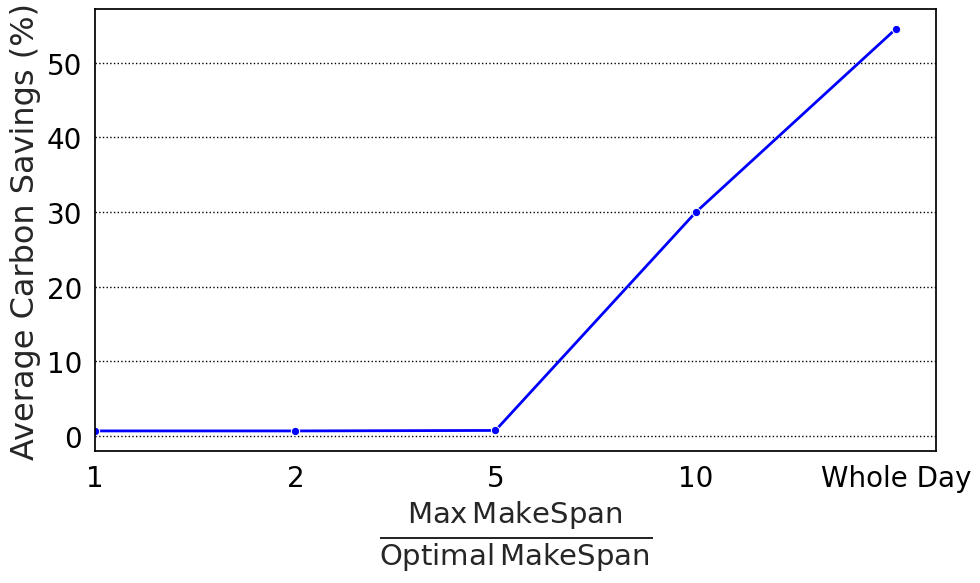

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn & matplotlib styling
sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_plot,
    x="x_label",
    y="CarbonSavings(%)",
    marker="o",
    linewidth=2,
    color="blue"
)

# Labels
ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
ax.set_ylabel("Average Carbon Savings (%)", fontsize=23)

# Axis limits and ticks
ax.set_xlim(left=0)
ax.set_xticks(ax.get_xticks())  # Maintain default ticks
ax.tick_params(axis='x', labelsize=20, color='black')
ax.tick_params(axis='y', labelsize=20, color='black')

# Grid settings
ax.grid(axis='x', visible=False)     # No grid on x-axis
ax.grid(axis='y', color='black', linestyle=':', linewidth=1)

# Black axes and ticks
ax.tick_params(axis='both', color='black', labelcolor='black')
for spine in ax.spines.values():
    spine.set_edgecolor('black')

plt.tight_layout()
plt.show()